## Team members (alphabetical order)

Jesus Torres (jesusst2) - Online MCS-DS: Everyone contributed initially for the overall discussion of how to divide work, discuss how each part was supposed to be solved. Primarily wrote parts 1 to 3

Saitejas Mopuri (smopuri2) - Online MCS-DS: Everyone contributed initially for the overall discussion of how to divide work, discuss how each part was supposed to be solved. Primarily wrote parts 4 and 5 and added text details

Sanika Kelkar (sanika2) - Online MCS-DS : Everyone contributed initially for the overall discussion of how to divide work, discuss how each part was supposed to be solved. Primarily responsible for overall testing, bugfixes and adding final text details / reviews before submission

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import scipy
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

#Using one of the student ids as seed
random_state = 5180
r = np.random.RandomState(random_state)

## Part 1: Generate Data
#### [1.1] First generate the 20 centers from two-dimensional normal. You can use any mean and covariance structure.  You should not regenerate the centers. Use these 20 centers throughout this simulation study.

#### [1.2]Given the 20 centers, generate a training sample of size 200 (100 from each class) and a test sample of size 10,000 (5,000 from each class).

#### [1.3] Produce a scatter plot of the training data: assign different colors to the two classes of data points; overlay the 20 centers on this scatter plot, using a distinguishing marker (e.g., a star or a different shape) and color them according to their respective class.

In [2]:
# 1.1
csize = 10      
p = 2      
s = 1 # sd for generating the centers within each class                    
m1 = r.normal(size = (csize, p)) * s \
     + np.concatenate([np.array([[1, 0]] * csize)])
m0 = r.normal(size = (csize, p)) * s \
     + np.concatenate([np.array([[0, 1]] * csize)])
y = [0] * 10 + [1] * 10
y = np.array(y)

In [3]:
# 1.2
s = np.sqrt(float(1)/5) 

def generate_train_test(csize, m0, m1, p, r):
    # train
    n = 100
    id1 = r.randint(csize, size = n)
    id0 = r.randint(csize, size = n)

    x_train = r.normal(size = (2 * n, p)) * s \
                + np.concatenate([m1[id1,:], m0[id0,:]])
    y_train = np.concatenate(([1]*n, [0]*n))

    # Test
    n = 5_000
    id1 = r.randint(csize, size = n)
    id0 = r.randint(csize, size = n)

    x_test = r.normal(size = (2 * n, p)) * s \
                + np.concatenate([m1[id1,:], m0[id0,:]])
    y_test = np.concatenate(([1]*n, [0]*n))

    return x_train, y_train, x_test, y_test

x_train, y_train, x_test, y_test = generate_train_test(csize,m0,m1,p,r)

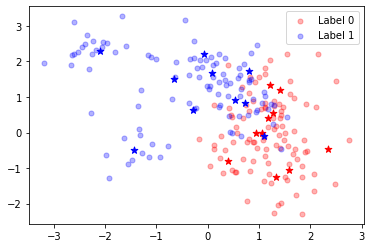

In [4]:
# 1.3
n = 100
plt.scatter(x=x_train[:n,0],y=x_train[:n,1],c='red',s=25,alpha=0.3,label='Label 0')
plt.scatter(x=x_train[n:,0],y=x_train[n:,1],c='blue',s=25,alpha=0.3,label = 'Label 1')
plt.scatter(x=m1[:,0],y=m1[:,1],c='red',marker='*',s=50)
plt.scatter(x=m0[:,0],y=m0[:,1],c='blue',marker='*',s=50)
plt.legend()

## Part 2: kNN
#### Implement kNN from scratch; use Euclidean Distance. Your implementation should meet the following requirements:

#### [2.1] Input: Your kNN function should accept three input parameters: training data, test data, and k. No need to write your kNN function to handle any general input; it suffices to write a function that is able to handle the data for this specific simulation study: binary classification; features are two-dimensional numerical vectors.
#### Output: Your function should return a vector of predictions for the test data.
#### Vectorization: Efficiently compute distances between all test points and training points simultaneously. Make predictions for all test points in a single operation.
#### No Loops: Do not use explicit loops like for or while inside your kNN function to compute distances or make predictions. Instead, harness the power of vectorized operations for efficient computations. For example, you can use broadcasting in Numpy or command outer in R.
#### Explain how you handle distance ties and voting ties; distance ties may occur when you have multiple (training) observations that are equidistant from a test observation. voting ties may occur when K is an even number and you have 50% of the k-nearest-neighbors from each of the two classes.


#### [2.2.1 and 2.2.2] Test your code with the training/test data you just generated when K = 1, 3, 5; and compare your results with knn in R or sklearn.neighbors in Python.

#### [2.3] Report your results (on the test data) as a 2-by-2 table (confusion matrix) for each K value.
#### Report the results from knn or sklearn.neighbors as a 2-by-2 table (confusion matrix) for each K value.

In [5]:
# 2.1
def kNN(X_train, y_train, test, k, print_):
    y_replicated = np.repeat([y_train], repeats = test.shape[0], axis=0)

    computation = np.sum(np.power(X_train - test[:, np.newaxis], 2), axis=2)
    # reference = https://stackoverflow.com/questions/69166483/numpy-calculate-difference-of-matrices-against-all-rows-in-matrix

    order = np.argsort(computation,axis=1)

    if print_: print("order\n",order)
    top_k = np.take_along_axis(y_replicated, order, axis=1)[:,:k]

    if print_: print("top k\n", top_k)
    mode = np.apply_along_axis(lambda x:Counter(x).most_common(1)[0][0],arr=top_k,axis=1)
    # reference = https://stackoverflow.com/questions/6252280/find-the-most-frequent-number-in-a-numpy-array
    
    return mode

In [6]:
# 2.2.1
def test_2_2_1():
    test = np.array([[1.0, 1.0],[0.0, 0.0]])
    y_train = np.array([1,2,1])
    train = np.array([[1, 1],[1, 1], [0, 0]])

    k = 2
    return kNN(train, y_train, test, 2, 1)
"""
I use argsort. 
In the documentation it is mentioned that it uses order to break up ties: https://numpy.org/doc/stable/reference/generated/numpy.argsort.html
In the first test, even when training sample 1 and 2 are at the same distance, it prioritizes the first
In the second test, even when training sample 1 and 2 are at the same distance, it prioritizes the first
"""
test_2_2_1()

order
 [[0 1 2]
 [2 0 1]]
top k
 [[1 2]
 [1 1]]


array([1, 1])

In [7]:
# 2.2.2
def test_2_2_2():
    test = np.array([[1.0, 1.0],[0.0, 0.0]])
    y_train = np.array([1,2,1])
    train = np.array([[1, 1],[1, 1], [0, 0]])

    k = 2
    return kNN(train, y_train, test, 2, 1)
"""
To count, I use most_common from Counter. Docs: https://docs.python.org/3/library/collections.html#collections.Counter
According to the documentation, in case of a tie, it returns the first encountered. In our scenario it would be the first training sample encountered
In the first test sample there is a tie between class 1 and 2, and it prioritizes the first class encountered: 1.
"""
test_2_2_2()

order
 [[0 1 2]
 [2 0 1]]
top k
 [[1 2]
 [1 1]]


array([1, 1])

In [8]:
# 2.3
for k in [1,3,5]:
    print("----------------------")
    print(f"Printing results for k={k}")
    print("-- My results")
    # mine
    y_pred_mine = kNN(x_train, y_train, x_test, k, 0)
    print(confusion_matrix(y_test,y_pred_mine))
    print("accuracy:",(y_test == y_pred_mine).mean())
    print("error:",(y_test != y_pred_mine).mean())
    print()

    # sklearn
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred_sk = model.predict(x_test)
    print("-- Sklearn results")
    print(confusion_matrix(y_test,y_pred_sk))
    print("accuracy:", (y_test == y_pred_sk).mean())
    print("error:",(y_test != y_pred_sk).mean())
    print()

----------------------
Printing results for k=1
-- My results
[[3775 1225]
 [ 758 4242]]
accuracy: 0.8017
error: 0.1983

-- Sklearn results
[[3775 1225]
 [ 758 4242]]
accuracy: 0.8017
error: 0.1983

----------------------
Printing results for k=3
-- My results
[[3887 1113]
 [ 642 4358]]
accuracy: 0.8245
error: 0.1755

-- Sklearn results
[[3887 1113]
 [ 642 4358]]
accuracy: 0.8245
error: 0.1755

----------------------
Printing results for k=5
-- My results
[[3861 1139]
 [ 561 4439]]
accuracy: 0.83
error: 0.17

-- Sklearn results
[[3861 1139]
 [ 561 4439]]
accuracy: 0.83
error: 0.17



### Part 3:cvKNN
### Implement KNN classification with K chosen by 10-fold cross-validation from scratch.

#### [3.1] Set the candidate K values from 1 to 180. (The maximum candidate K value is 180. Why?)
#### From now on, you are allowed to use the built-in kNN function from R or Python instead of your own implementation from Part 2.
#### It is possible that multiple K values give the (same) smallest CV error; when this happens, pick the largest K value among them, since the larger the K value, the simpler the model.
#### [3.2] Test your code with the training/test data you just generated. Report your results (on the test data) as a 2-by-2 table and also report the value of the selected K.

In [9]:
# 3.
def cvKNN(x_train, y_train):
    errors = [0] * 180
    n = x_train.shape[0]
    indx_cv = np.arange(n) % 10
    for k in range(1, 181):
        model = KNeighborsClassifier(n_neighbors=k)

        err = 0
        for i in range(10):
            x_train_temp = x_train[indx_cv!=i]
            y_train_temp = y_train[indx_cv!=i]

            x_test_temp = x_train[indx_cv==i]
            y_test_temp = y_train[indx_cv==i]

            model.fit(x_train_temp,y_train_temp)
            err += (model.predict(x_test_temp) != y_test_temp).sum()
        #k values are from 1 to 180 but python lists are indexed from 0 to 179. So index = k-1
        errors[k-1] = err

    min_err = np.min(errors)
    #Find indexes where min k has been found
    possible_ks = np.where(errors==min_err)
    #Find the max index (highest value of k where error is min)
    best_k = max(possible_ks[0])
    #The actual k value is the index+1
    return best_k+1

In [17]:
best_k = cvKNN(x_train, y_train)
best_k

136

3.1.1: Why K = 180 is maximum?

In 10-fold, our training data gets split into 180 for training and 20 for testing.
Therefore, We can't use more than K=180 (the whole training set in 10-fold)


In [11]:
# 3.2
new_model = KNeighborsClassifier(n_neighbors=122)
new_model.fit(x_train, y_train)
y_new_model = new_model.predict(x_test)
print("accuracy:", (y_new_model == y_test).mean())
print("error:", (y_new_model != y_test).mean())

confusion_matrix(y_test, y_new_model)

accuracy: 0.8237
error: 0.1763


array([[3565, 1435],
       [ 328, 4672]], dtype=int64)

### Part 4: Bayes rule
#### [4.1] Implement the Bayes rule. Your implementation should meet the following requirements:
#### [4.2] Report your results (on the test data) as a 2-by-2 table.

In [12]:
# 4.1
def bayes_rule(x_test, m1, m0, s):
    numerator = 0
    denominator = 0
    for i in range(10):
        numerator += np.exp(-np.sum((x_test-m1[i,:])**2,axis=1)/(2*s**2))
        denominator += np.exp(-np.sum((x_test-m0[i,:])**2,axis=1)/(2*s**2))
    return (numerator / denominator >= 1).astype(int)

y_pred = bayes_rule(x_test, m1, m0, s)
print("accuracy:", (y_pred == y_test).mean())
print("error:", (y_pred != y_test).mean())

accuracy: 0.86
error: 0.14


In [13]:
# 4.2
confusion_matrix(y_test, y_pred)

array([[4016,  984],
       [ 416, 4584]], dtype=int64)

### Part 5: Simulation Study
#### Given the 20 centers generated in Part 1, repeatedly generate 50 training/test datasets (training size = 200 and test size = 10,000). For each pair of training/test datasets, calculate the test errors (the averaged 0/1 loss on the test data set) for each of the following three procedures:

#### kNN with K = 7 (you can use the built-in kNN function from R or Python);
#### kNN with K chosen by 10-fold CV (your implementation from Part 3); and
#### the Bayes rule (your implementation from Part 4).
#### Present the test errors graphically, e.g., using a boxplot or strip chart (see below). Also, report the (min, max, median, 25% quantile, 75% quantile) for the 50 selected K values.

In [14]:
# 5
# This takes a couple of minutes to run
results = [[0,0,0] for _ in range(50)]
best_ks = [0 for _ in range(50)]

for i in range(50):
    if i % 5 == 0: print(i)
    x_train, y_train, x_test, y_test = generate_train_test(csize,m0,m1,p,r)

    # model1
    model1 = KNeighborsClassifier(n_neighbors=7)
    model1.fit(x_train, y_train)
    y_pred1 = model1.predict(x_test)

    #model2
    best_k = cvKNN(x_train, y_train)
    model2 = KNeighborsClassifier(n_neighbors=best_k)
    model2.fit(x_train, y_train)
    y_pred2 = model2.predict(x_test)

    #model3
    y_pred3 = bayes_rule(x_test, m1, m0, s)

    best_ks[i] = best_k
    results[i] = [(y_pred1!=y_test).mean(),(y_pred2!=y_test).mean(),(y_pred3!=y_test).mean()]

0
5
10
15
20
25
30
35
40
45


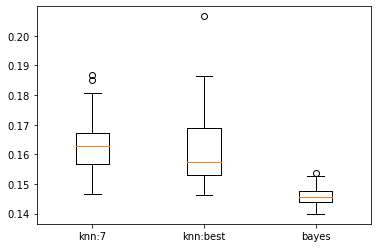

In [15]:
results = np.array(results)
plt.boxplot(results, labels=["knn:7", "knn:best", "bayes"]);

In [16]:
best_ks_series = pd.Series(best_ks)
best_ks_series.describe()

count     50.000000
mean      80.080000
std       52.529036
min        5.000000
25%       35.250000
50%       67.500000
75%      129.000000
max      178.000000
dtype: float64